# Customer Churn & Retention Analytics — Step 4: Create Customer Segments

Step 3 found the drivers of churn (contract type, tenure, missing add-ons, fiber optic, electronic check). This step turns those drivers into actual customer segments — something the business can act on, rather than just a list of correlations.

Two segments to build:
1. **Risk tier** — how likely is this customer to churn, based on the drivers confirmed in EDA
2. **Value tier** — how much revenue does this customer represent

Combining the two gives a segment matrix that's directly useful for prioritizing retention effort (e.g. don't spend the same energy retaining a low-value, low-risk customer as a high-value, high-risk one).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('telco_churn_cleaned.csv')
df.shape

(7043, 21)

## Building the risk score

This is a rule-based score, not a model — the point weights come directly from what Step 3 found. I'm keeping this separate from the ML model in Step 7 on purpose: this is a transparent, explainable "business logic" segment that a non-technical stakeholder can understand just by reading the rules, while the ML model in Step 7 is meant to be a more accurate but less interpretable probability score. Having both is useful — the ML step can later be checked against this simpler segmentation as a sanity check.

Weights, roughly following the chi-square ranking from Step 3 (bigger effect size = more points):
- **Contract**: Month-to-month = 3, One year = 1, Two year = 0
- **Tenure**: 0-6 months = 3, down to 49+ months = 0
- **OnlineSecurity / TechSupport** missing = 1 point each (these had the largest chi2 among the add-on columns)
- **OnlineBackup / DeviceProtection** missing = 0.5 points each (still significant, smaller effect)
- **Fiber optic internet** = 1 point (highest churn rate InternetService category)
- **Electronic check payment** = 1 point (highest churn rate PaymentMethod category)

In [2]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 72],
                             labels=['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'])

risk_score = pd.Series(0.0, index=df.index)
risk_score += df['Contract'].map({'Month-to-month': 3, 'One year': 1, 'Two year': 0})
risk_score += df['tenure_group'].map({'0-6 mo': 3, '7-12 mo': 2, '13-24 mo': 1, '25-48 mo': 0.5, '49-72 mo': 0}).astype(float)
risk_score += (df['OnlineSecurity'] == 'No').astype(int) * 1
risk_score += (df['TechSupport'] == 'No').astype(int) * 1
risk_score += (df['OnlineBackup'] == 'No').astype(int) * 0.5
risk_score += (df['DeviceProtection'] == 'No').astype(int) * 0.5
risk_score += (df['InternetService'] == 'Fiber optic').astype(int) * 1
risk_score += (df['PaymentMethod'] == 'Electronic check').astype(int) * 1

df['risk_score'] = risk_score
df['risk_score'].describe()

count    7043.000000
mean        5.153415
std         3.319535
min         0.000000
25%         2.000000
50%         5.500000
75%         8.000000
max        11.000000
Name: risk_score, dtype: float64

Splitting into four risk tiers using quartiles of the score, then checking this actually correlates with real churn before trusting it for anything downstream.

In [3]:
df['risk_tier'] = pd.qcut(df['risk_score'], q=4, labels=['Low', 'Medium', 'High', 'Critical'], duplicates='drop')

validation = df.groupby('risk_tier', observed=True).agg(
    customers=('Churn', 'size'),
    churn_rate_pct=('Churn', lambda x: round((x == 'Yes').mean() * 100, 2))
)
validation

,customers,churn_rate_pct
risk_tier,,
Low,1882,2.71
Medium,1790,12.12
High,1871,34.10
Critical,1500,64.20


Churn rate climbs cleanly from Low to Critical — 2.7% → 12.1% → 34.1% → 64.2%. That's a strong, monotonic relationship, which means the rule-based score is actually capturing something real and not just noise. This is the check that matters most here: a segmentation is only useful if it separates customers who behave differently, and this one clearly does.

C:\Users\dwara\AppData\Local\Temp\ipykernel_39988\756897107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=validation.index, y=validation['churn_rate_pct'], order=order, palette='Reds', ax=ax)


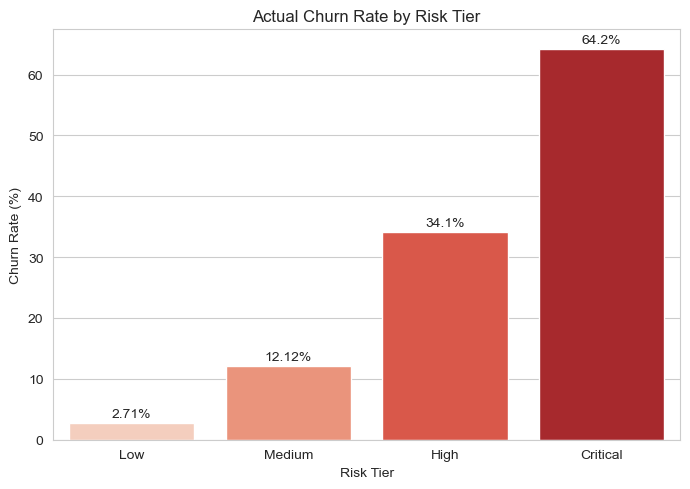

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ['Low', 'Medium', 'High', 'Critical']
sns.barplot(x=validation.index, y=validation['churn_rate_pct'], order=order, palette='Reds', ax=ax)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Risk Tier')
ax.set_title('Actual Churn Rate by Risk Tier')
for i, v in enumerate(validation.loc[order, 'churn_rate_pct']):
    ax.text(i, v + 1, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## Building the value tier

Splitting customers into three value tiers by `MonthlyCharges` — this is what determines how much revenue is actually on the line for a given customer, separate from how likely they are to leave.

In [5]:
df['value_tier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])

df.groupby('value_tier', observed=True)['MonthlyCharges'].agg(['count', 'min', 'max', 'mean']).round(2)

,count,min,max,mean
value_tier,,,,
Low Value,2351,18.25,50.40,27.99
Medium Value,2345,50.45,83.90,69.04
High Value,2347,83.95,118.75,97.33


## Combining risk and value into business segments

This is the actual output the business can act on. Simplifying the 4x3 risk-by-value grid down to a handful of named segments, prioritized by where retention effort should actually go.

In [6]:
def assign_segment(row):
    risk = row['risk_tier']
    value = row['value_tier']

    if risk == 'Critical' and value == 'High Value':
        return 'Critical - High Value at Risk'
    elif risk == 'Critical':
        return 'Critical - At Risk'
    elif risk == 'High' and value in ['High Value', 'Medium Value']:
        return 'High Risk - Monitor Closely'
    elif risk == 'High':
        return 'High Risk - Low Value'
    elif risk == 'Medium':
        return 'Medium Risk - Watch'
    else:
        return 'Low Risk - Stable'

df['business_segment'] = df.apply(assign_segment, axis=1)

segment_summary = df.groupby('business_segment').agg(
    customers=('Churn', 'size'),
    churn_rate_pct=('Churn', lambda x: round((x == 'Yes').mean() * 100, 2)),
    avg_monthly_charge=('MonthlyCharges', lambda x: round(x.mean(), 2)),
    total_monthly_revenue=('MonthlyCharges', lambda x: round(x.sum(), 2))
).sort_values('churn_rate_pct', ascending=False)

segment_summary

,customers,churn_rate_pct,avg_monthly_charge,total_monthly_revenue
business_segment,,,,
Critical - High Value at Risk,469,70.58,91.61,42966.80
Critical - At Risk,1031,61.30,63.26,65216.50
High Risk - Monitor Closely,1270,37.72,83.61,106187.55
High Risk - Low Value,601,26.46,30.19,18145.10
Medium Risk - Watch,1790,12.12,69.31,124057.40
Low Risk - Stable,1882,2.71,52.89,99543.25


C:\Users\dwara\AppData\Local\Temp\ipykernel_39988\858594609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary['customers'], y=order, palette='Reds_r', ax=ax)


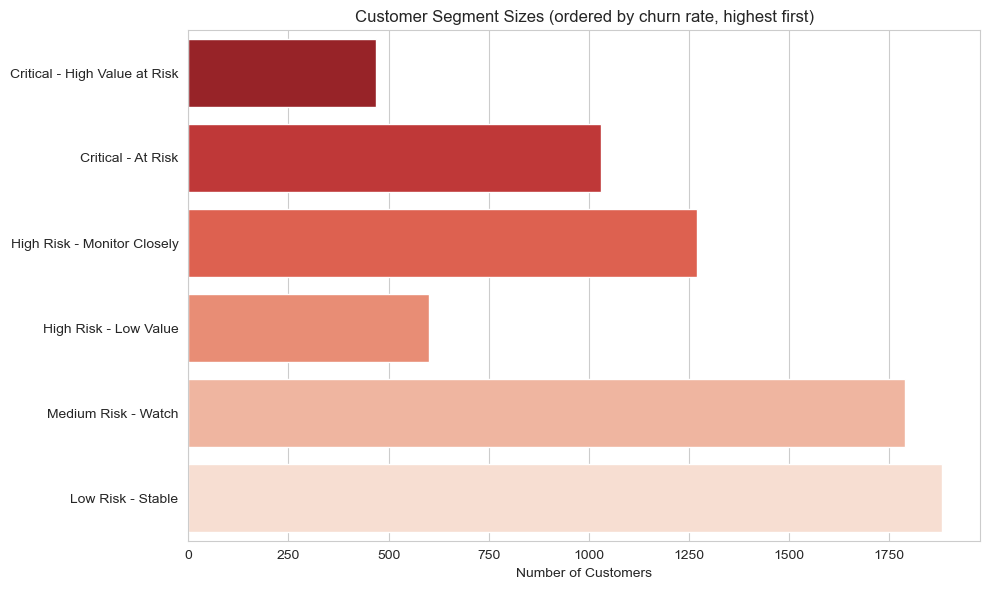

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
order = segment_summary.index.tolist()
sns.barplot(x=segment_summary['customers'], y=order, palette='Reds_r', ax=ax)
ax.set_xlabel('Number of Customers')
ax.set_title('Customer Segment Sizes (ordered by churn rate, highest first)')
plt.tight_layout()
plt.show()

**"Critical - High Value at Risk"** is the segment that matters most: these are customers who are both very likely to churn AND represent meaningful revenue. This is the group a retention campaign should target first — the "why are they leaving" and "what should the company do" questions from the project brief are really about this segment specifically, not the whole customer base.

## Save the segmented dataset

This becomes the file Step 5 loads into SQL, and what later steps (ML, revenue calculations, Power BI) all build on.

In [8]:
df.to_csv('telco_churn_segmented.csv', index=False)
print(f"Saved: {df.shape[0]} rows, {df.shape[1]} columns")
print()
print(df[['customerID', 'Churn', 'risk_score', 'risk_tier', 'value_tier', 'business_segment']].head())

Saved: 7043 rows, 26 columns

   customerID Churn  risk_score risk_tier    value_tier  \
0  7590-VHVEG    No         9.5  Critical     Low Value   
1  5575-GNVDE    No         3.0    Medium  Medium Value   
2  3668-QPYBK   Yes         7.5      High  Medium Value   
3  7795-CFOCW    No         2.0       Low     Low Value   
4  9237-HQITU   Yes        11.0  Critical  Medium Value   

              business_segment  
0           Critical - At Risk  
1          Medium Risk - Watch  
2  High Risk - Monitor Closely  
3            Low Risk - Stable  
4           Critical - At Risk  


## Summary

- Built a transparent, rule-based `risk_score` from the drivers confirmed in Step 3 (contract type, tenure, missing add-ons, fiber optic, electronic check)
- Validated it against real churn: churn rate rises cleanly from 2.7% (Low) to 64.2% (Critical) across the four tiers — the score is capturing a real pattern, not noise
- Added a `value_tier` based on MonthlyCharges to bring revenue into the picture, not just churn probability
- Combined both into named business segments, with **"Critical - High Value at Risk"** as the top-priority group for retention
- Saved as `telco_churn_segmented.csv` for the SQL and Power BI steps ahead

Next: load this into SQL and write the 10-15 business queries (Step 5-6).